In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import pyiga

import scipy
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csc_matrix, csr_matrix, coo_matrix
from scipy.sparse.linalg import aslinearoperator

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

from pyiga import bspline, assemble, vform, geometry, vis, solvers, topology, bspline_cy


In [5]:
(p1,p2)=(1,2)
l=5

In [10]:
np.repeat((p1,p2),l,axis=-1)

array([1, 1, 1, 1, 1, 2, 2, 2, 2, 2])

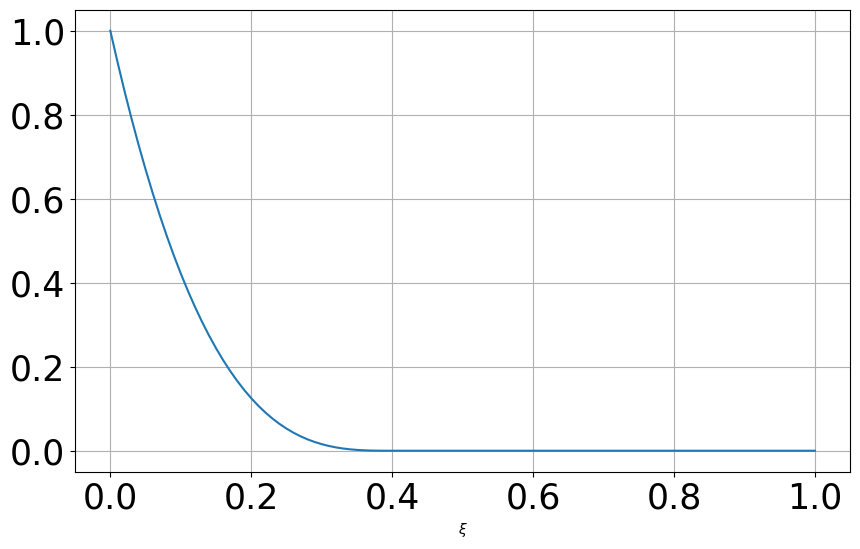

In [4]:
p=3
nu=0.4
psi=lambda t: (np.maximum(1-t/nu,0))**p
t = np.linspace(0,1,101)
fig = plt.figure(figsize=(10,6))
plt.plot(t,np.vectorize(psi)(t));
plt.grid(True);
plt.xlabel(r"$\xi$");
plt.xticks(fontsize=25);
plt.yticks(fontsize=25);
plt.savefig('/home/wolfman/Pictures/Extensionfunction.png',bbox_inches='tight',dpi=300);

In [9]:
psi_2D = lambda s,t: psi(s)*psi(t) 

In [10]:
x = np.linspace(0,1, 1001)
y = np.linspace(0,1, 1001)
X, Y = np.meshgrid(x, y)

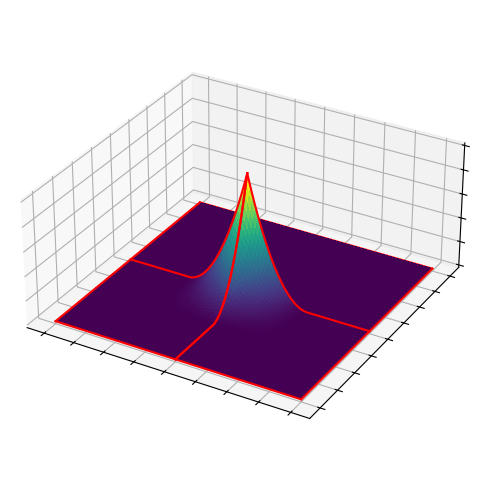

In [76]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(projection='3d')

ax.plot_surface(X, Y, psi_2D(1-X,1-Y), cmap='viridis',zorder=3,antialiased=False,shade=True)
ax.plot_surface(X+1, Y, psi_2D(X,1-Y), cmap='viridis',zorder=3,antialiased=False,shade=True)
ax.plot_surface(2*X,Y+1,np.zeros_like(X), cmap='viridis',zorder=1,antialiased=False,shade=True)
ax.plot(y,1,psi(1-x),color='red',zorder=1000)
ax.plot(1,y,psi(1-y),color='red',zorder=1000)
ax.plot(x+1,1,psi(x),color='red',zorder=1000)
ax.plot(1,y,psi(1-y),color='red',zorder=1000)
ax.plot(0,y,0,color='red',zorder=1000)
ax.plot(x,0,0,color='red',zorder=1000)
ax.plot(x+1,0,0,color='red',zorder=1000)
ax.plot(2,y,0,color='red',zorder=1000)
ax.plot(0,y+1,0,color='red',zorder=1000)
ax.plot(2*x,2,0,color='red',zorder=2)
#ax.plot(2*x,2,0,color='red',zorder=1000)
ax.plot(2,y+1,0,color='red',zorder=1000)
plt.axis('scaled');
ax.tick_params(labelbottom=False, labelleft=False)
ax.grid(True)
plt.savefig('/home/wolfman/Pictures/VertexExtension.png',bbox_inches='tight',dpi=300);

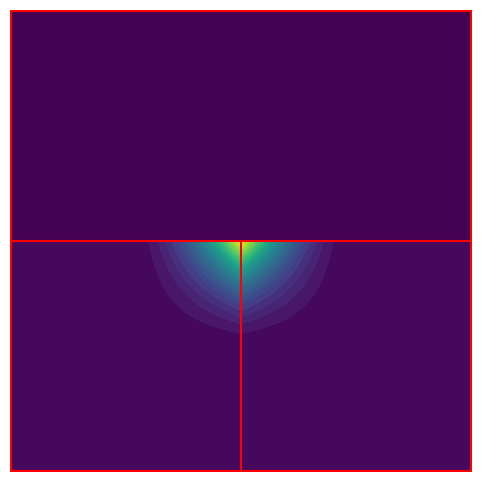

In [79]:
fig = plt.figure(figsize=(6,6))
plt.contourf(2*X,Y+1,np.zeros_like(Y),levels=30, vmin=0, vmax=1)
plt.contourf(X, Y, psi_2D(1-X,1-Y), levels=30)
plt.contourf(X+1, Y, psi_2D(X,1-Y), levels=30)
plt.plot([0,0],[1,0],color='red',zorder=1000, linewidth=3)
plt.plot([0,2],[0,0],color='red',zorder=1000, linewidth=3)
plt.plot([1,1],[1,0],color='red',zorder=1000, linewidth=1.5)
plt.plot([2,2],[1,0],color='red',zorder=1000, linewidth=3)
plt.plot([0,2],[1,1],color='red',zorder=1000, linewidth=1.5)
plt.plot([0,0],[1,2],color='red',zorder=1000, linewidth=3)
plt.plot([0,2],[2,2],color='red',zorder=1000, linewidth=3)
plt.plot([2,2],[1,2],color='red',zorder=1000, linewidth=3)
#plt.plot(np.zeros_like(y),y,color='red',zorder=1000, linewidth=5)
#plt.plot(np.zeros_like(y),y,color='red',zorder=1000, linewidth=5)
plt.axis('scaled');
plt.axis('off');
#plt.show();
plt.savefig('/home/wolfman/Pictures/VertexExtensionContour.png',bbox_inches='tight',dpi=300);

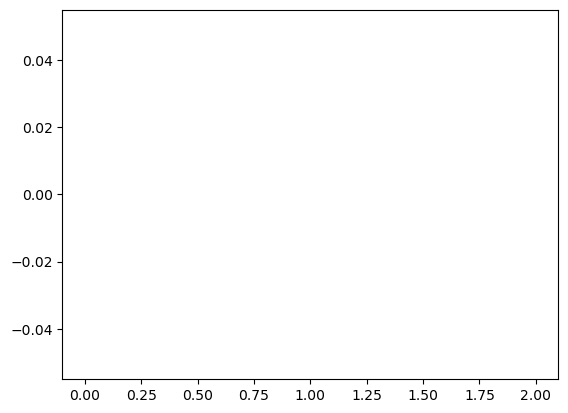

In [25]:
plt.plot(0,0,2,0,color='red', linewidth=5);

In [26]:
u = lambda t: 0.1*np.sin(5*np.pi*t)+t*(1-t)

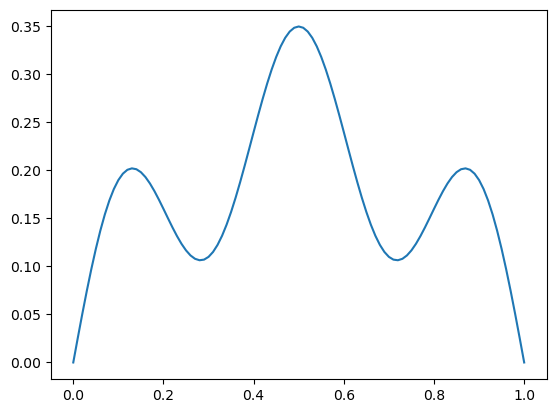

In [27]:
plt.plot(t,u(t))

In [28]:
psi_Gamma = lambda s,t: u(s)*psi(1-t)

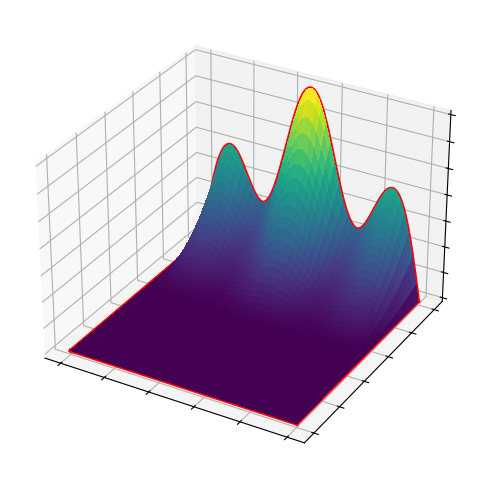

In [63]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(projection='3d')

ax.plot_surface(X, Y, psi_Gamma(X,Y), cmap='viridis', antialiased=False,shade=True)
ax.plot(x,1,u(x),color='red',linewidth=3)
ax.plot(x,0,0,color='red',linewidth=3)
ax.plot(0,y,0,color='red',linewidth=3)
ax.plot(1,y,0,color='red',linewidth=3)
ax.tick_params(labelbottom=False, labelleft=False)
ax.grid(True)
plt.savefig('/home/wolfman/Pictures/EdgeExtension.png',bbox_inches='tight',dpi=300);

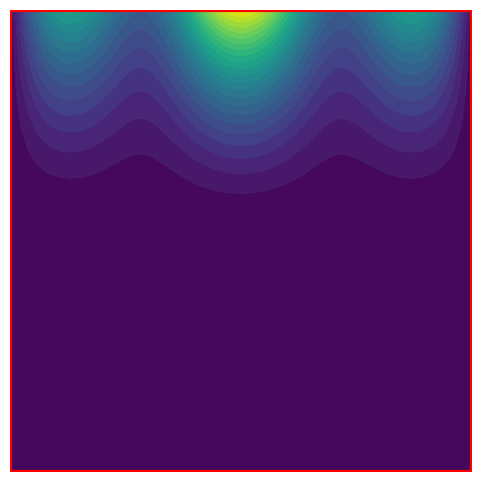

In [64]:
fig = plt.figure(figsize=(6,6))
plt.contourf(X, Y, psi_Gamma(X,Y), levels=30)
plt.plot([0,0],[1,0],color='red',zorder=1000, linewidth=3)
plt.plot([0,1],[0,0],color='red',zorder=1000, linewidth=3)
plt.plot([1,1],[1,0],color='red',zorder=1000, linewidth=3)
plt.plot([0,1],[1,1],color='red',zorder=1000, linewidth=3)
plt.axis('scaled');
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/EdgeExtensionContour.png',bbox_inches='tight',dpi=300);

In [111]:
X

array([[0.   , 0.001, 0.002, ..., 0.998, 0.999, 1.   ],
       [0.   , 0.001, 0.002, ..., 0.998, 0.999, 1.   ],
       [0.   , 0.001, 0.002, ..., 0.998, 0.999, 1.   ],
       ...,
       [0.   , 0.001, 0.002, ..., 0.998, 0.999, 1.   ],
       [0.   , 0.001, 0.002, ..., 0.998, 0.999, 1.   ],
       [0.   , 0.001, 0.002, ..., 0.998, 0.999, 1.   ]], shape=(1001, 1001))

In [112]:
Y

array([[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
       [0.001, 0.001, 0.001, ..., 0.001, 0.001, 0.001],
       [0.002, 0.002, 0.002, ..., 0.002, 0.002, 0.002],
       ...,
       [0.998, 0.998, 0.998, ..., 0.998, 0.998, 0.998],
       [0.999, 0.999, 0.999, ..., 0.999, 0.999, 0.999],
       [1.   , 1.   , 1.   , ..., 1.   , 1.   , 1.   ]], shape=(1001, 1001))